<a href="https://colab.research.google.com/github/Z4nata/CalculoNum-rico/blob/main/Atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática II — Estabilidade Numérica e Overflow em CFD Simplificado
**Disciplina:** Cálculo Numérico — Prof. Raquel J. Lobosco
**Aluno:** _Felipe Pinto Zanata_




## 0. Implementação (código fornecido no enunciado)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    '''Simula difusao de velocidade e detecta falhas (overflow / invalid).'''
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (u[2:] - dois * u[1:-1] + u[:-2])
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "dy": dy,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308


## 1. Verificação da estabilidade



In [2]:
H, nu, pontos = 0.01, 1e-4, 21
dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)

casos = {"A": 0.001, "B": 0.002}
print(f"dy      = {dy} m")
print(f"dt_max  = {dt_max} s\n")

for nome, dt in casos.items():
    r = nu * dt / dy**2
    situacao = "ESTAVEL (r <= 1/2)" if r <= 0.5 else "INSTAVEL (r > 1/2)"
    print(f"Caso {nome}: dt={dt} s -> r={r:.3f}  =>  {situacao}")

dy      = 0.0005 m
dt_max  = 0.0012499999999999998 s

Caso A: dt=0.001 s -> r=0.400  =>  ESTAVEL (r <= 1/2)
Caso B: dt=0.002 s -> r=0.800  =>  INSTAVEL (r > 1/2)


## 2. Detecção de overflow

Execução dos quatro testes

In [3]:
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


In [4]:
linhas = []
for nome, res in resultados.items():
    tipo_nome, dt_txt = nome.split(", ")
    linhas.append({
        "Tipo numérico": tipo_nome,
        "Δt (s)": float(dt_txt.split("=")[1]),
        "r": round(res["r"], 3),
        "Overflow?": "Sim" if res["falha"] is not None else "Não",
        "Iteração da falha": res["falha"] if res["falha"] is not None else "-",
        "t da falha (s)": round(res["falha"] * float(dt_txt.split("=")[1]), 4) if res["falha"] is not None else "-",
    })

tabela = pd.DataFrame(linhas)
tabela

,Tipo numérico,Δt (s),r,Overflow?,Iteração da falha,t da falha (s)
0,float32,0.001,0.4,Não,-,-
1,float32,0.002,0.8,Sim,121,0.242
2,float64,0.001,0.4,Não,-,-
3,float64,0.002,0.8,Sim,917,1.834


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


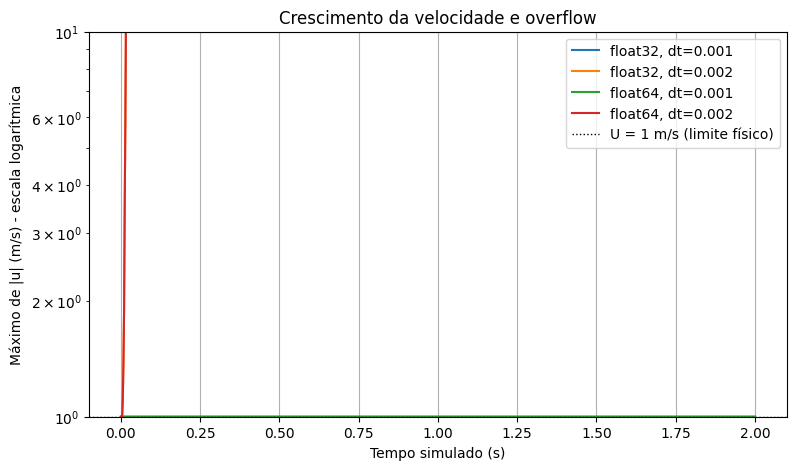

In [5]:
plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )
plt.axhline(1.0, color="k", linestyle=":", linewidth=1, label="U = 1 m/s (limite físico)")
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) - escala logarítmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

## 3. Interpretação física

No caso estável (\(r = 0,4\)), o valor máximo da velocidade aumenta rápido até chegar perto de \(U = 1\) m/s e depois praticamente não muda mais. Isso acontece porque o fluido perto da placa acaba atingindo a velocidade da placa, e essa velocidade vai se espalhando aos poucos para o restante do fluido. Esse é o comportamento esperado, já que a velocidade não deveria passar de \(U\), pois a única fonte de movimento é a própria placa.

Já no caso instável (\(r = 0,8\)), o comportamento é bem diferente. Depois de um tempo, a velocidade máxima começa a crescer muito rápido, passando de \(U = 1\) m/s por várias ordens de grandeza até ocorrer o overflow. Isso não faz sentido fisicamente, porque não existe nada no problema que faça o fluido ficar muito mais rápido que a placa. Esse crescimento acontece por causa do método numérico. Quando \(r > 0,5\), o termo \((1-2r)\) fica negativo, então a fórmula deixa de fazer uma média dos valores vizinhos. Com isso, pequenos erros e perturbações vão sendo aumentados a cada passo de tempo, gerando oscilações cada vez maiores até que os valores fiquem grandes demais para o computador representar, causando o overflow.

## 4. Capacidade de representação

Comparando os dois tipos numéricos no caso instável (\(r=0,8\)), o **float32** apresenta overflow no passo 121 (\(t \approx 0,242\) s), enquanto o **float64** só apresenta no passo 917 (\(t \approx 1,834\) s), ou seja, cerca de **7,5 vezes mais tarde**.

Trocar o tipo numérico não resolve a instabilidade. Nos dois casos, a solução continua crescendo exponencialmente, porque o problema está no próprio método numérico, já que \(r>1/2\), e não na precisão do computador.

A diferença é que o **float64 consegue representar números muito maiores** antes de ocorrer o overflow. O float32 chega até aproximadamente \(3,4\times10^{38}\), enquanto o float64 chega a aproximadamente \(1,8\times10^{308}\).

Como o erro vai aumentando a cada passo, o float64 demora muito mais para atingir esse limite. Por isso ele parece funcionar por mais tempo, mas a instabilidade continua existindo.

Então, **o float64 apenas atrasa o overflow, mas não corrige o problema**. Para resolver a instabilidade, seria necessário usar um \(\Delta t\) dentro do limite de estabilidade do método.


## 5. Refinamento da malha


In [6]:
H, nu = 0.01, 1e-4
pontos_novo = 41
dy_novo = H / (pontos_novo - 1)
dt_max_novo = dy_novo**2 / (2 * nu)
dt_teste = 0.001
r_novo = nu * dt_teste / dy_novo**2
print(f"pontos={pontos_novo}: dy={dy_novo} m, dt_max={dt_max_novo:.7f} s")
print(f"Com dt={dt_teste} s -> r={r_novo:.3f} ({'instavel' if r_novo>0.5 else 'estavel'})\n")

resultado_41_instavel = simular(dt_teste, np.float64, passos=2000, pontos=pontos_novo)

pontos=41: dy=0.00025 m, dt_max=0.0003125 s
Com dt=0.001 s -> r=1.600 (instavel)

dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract


Como esperado, a simulação com **41 pontos** e o mesmo \(\Delta t=0,001\) s do caso A diverge e apresenta *overflow*. Isso acontece porque \(r=1,6\) está muito acima do limite de estabilidade, que é \(1/2\).

Ou seja, apenas aumentar a quantidade de pontos da malha, sem diminuir o passo de tempo, fez com que a simulação que antes era estável se tornasse instável. Isso acontece porque, no método explícito, o valor máximo de \(\Delta t\) diminui conforme a malha espacial fica mais refinada.

Agora, repetindo o teste com um passo de tempo menor, por exemplo \(\Delta t=0,0001\) s, temos \(r\approx0,16\), que está dentro do limite de estabilidade:


In [7]:
dt_estavel_41 = 0.0001
r_estavel_41 = nu * dt_estavel_41 / dy_novo**2
print(f"dt={dt_estavel_41} s -> r={r_estavel_41:.3f} ({'instavel' if r_estavel_41>0.5 else 'estavel'})\n")

resultado_41_estavel = simular(dt_estavel_41, np.float64, passos=20000, pontos=pontos_novo)

dt=0.0001 s -> r=0.160 (estavel)

dt=0.0001, float64: 20000 passos sem overflow.


Com \(\Delta t=0,0001\) s (\(r\approx0,16\)), que está dentro do limite de estabilidade \(r\leq1/2\), a simulação com a malha refinada consegue rodar os 20000 passos sem apresentar *overflow*. Além disso, a velocidade máxima chega a \(U=1\) m/s e se mantém nesse valor, como era esperado fisicamente.

Isso confirma que o problema de instabilidade acontecia porque o limite \(r\leq1/2\) não estava sendo respeitado. Para corrigir isso, foi necessário diminuir o \(\Delta t\) junto com o refinamento da malha. Como o limite depende de \(\Delta y^2\), uma redução de \(\Delta y\) exige uma redução ainda maior no \(\Delta t\).


## 6. Verificação do perfil de velocidade



In [8]:
U = 1.0

def perfil_estacionario(y, H=0.01, U=1.0):
    return U * (1 - y / H)

def erro_inf(u, y):
    return float(np.max(np.abs(u - perfil_estacionario(y))))

for passos_teste in (200, 500, 1000, 2000):
    res = simular(0.001, np.float64, passos=passos_teste, pontos=21)
    E = erro_inf(res["u"], res["y"])
    print(f"passos={passos_teste:5d}  t={res['tempos'][-1]:.3f} s   E_inf = {E:.3e}")

dt=0.001, float64: 200 passos sem overflow.
passos=  200  t=0.200 s   E_inf = 8.775e-02
dt=0.001, float64: 500 passos sem overflow.
passos=  500  t=0.500 s   E_inf = 4.504e-03
dt=0.001, float64: 1000 passos sem overflow.
passos= 1000  t=1.000 s   E_inf = 3.194e-05
dt=0.001, float64: 2000 passos sem overflow.
passos= 2000  t=2.000 s   E_inf = 1.605e-09


dt=0.001, float64: 2000 passos sem overflow.


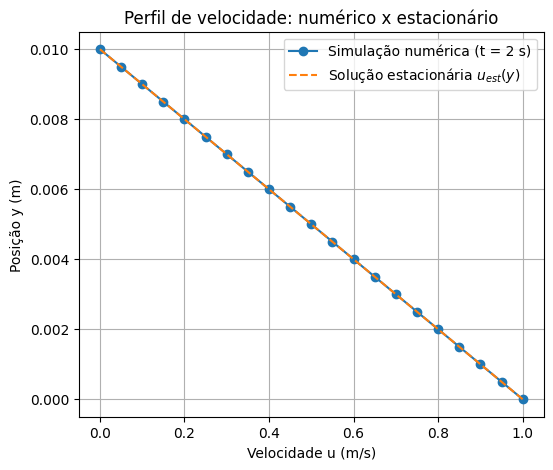

E_inf = max|u_i - u_est(y_i)| = 1.605e-09 m/s


In [9]:
resultado_final = simular(0.001, np.float64, passos=2000, pontos=21)
y = resultado_final["y"]
u_final = resultado_final["u"]
uest = perfil_estacionario(y)
E_inf = erro_inf(u_final, y)

plt.figure(figsize=(6, 5))
plt.plot(u_final, y, "o-", label="Simulação numérica (t = 2 s)")
plt.plot(uest, y, "--", label="Solução estacionária $u_{est}(y)$")
plt.xlabel("Velocidade u (m/s)")
plt.ylabel("Posição y (m)")
plt.title("Perfil de velocidade: numérico x estacionário")
plt.legend()
plt.grid(True)
plt.show()

print(f"E_inf = max|u_i - u_est(y_i)| = {E_inf:.3e} m/s")

O erro máximo \(E_\infty\) em \(t=2\) s, depois de 2000 passos, ficou na ordem de \(10^{-9}\) m/s, que é praticamente o erro de arredondamento do `float64`. Isso mostra que o período de transiente já praticamente terminou.

Isso faz sentido considerando o tempo característico de difusão, \(\tau=H^2/\nu=1\) s. Como a simulação chegou a \(t=2\) s, ou seja, aproximadamente \(2\tau\), o sistema já está bem próximo do estado estacionário.

A tabela também mostra isso: em \(t=0,2\) s, o erro ainda era de aproximadamente \(10^{-2}\) m/s, indicando que o transiente ainda estava acontecendo. Já em \(t=2\) s, o erro caiu para aproximadamente \(10^{-9}\) m/s.

Assim, o tempo usado no Caso A foi suficiente para chegar muito próximo do regime estacionário. Se a simulação tivesse sido muito curta, por exemplo, com apenas algumas dezenas de passos, o erro ainda teria uma parte significativa causada pelo transiente, e não somente pelo erro numérico.


## 7. Conclusão

* O método explícito usado na simulação é estável apenas quando \(r=\nu\Delta t/\Delta y^2\leq1/2\). Esse limite está relacionado ao método numérico, e não ao comportamento físico do problema.

* **Refinar a malha** diminui o erro espacial, mas também exige diminuir o passo de tempo. Isso acontece porque o limite de \(\Delta t\) depende de \(\Delta y^2\). Por isso, ao passar de 21 para 41 pontos e manter o mesmo \(\Delta t\), a simulação ficou instável.

* **Instabilidade e overflow são coisas diferentes.** A instabilidade acontece quando \(r>1/2\) e faz os valores começarem a crescer de forma exagerada. O overflow só aparece depois, quando esses valores ficam grandes demais para serem representados pelo computador.

* Trocar `float32` por `float64` **não resolve a instabilidade**. O `float64` apenas consegue representar números maiores, então o overflow demora mais para acontecer. A solução já está errada antes mesmo de ocorrer o overflow.

* O que realmente resolveu o problema foi **diminuir o \(\Delta t\)** para manter \(r\leq1/2\). Para a malha de 21 pontos, foi usado \(\Delta t=0,001\) s, enquanto para 41 pontos foi necessário usar um valor menor, como \(\Delta t=0,0001\) s.

Com \(r\leq1/2\), a simulação permanece estável e a velocidade fica dentro do esperado, \(0\leq u\leq U\), convergindo aos poucos para o perfil linear de velocidade do estado estacionário.
